<a href="https://colab.research.google.com/github/franksalomon/home-credit-default-risk-tfm/blob/main/TFM_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Carga de librerías y datos

En esta primera etapa se importan las librerías necesarias, se descarga el conjunto de datos y se cargan las tablas principales que se utilizarán en el análisis. La tabla `application_train` será la base principal del modelo, mientras que `bureau` y `previous_application` se usarán posteriormente para construir variables agregadas a nivel de cliente.

In [1]:
# =========================================================
# 1. IMPORTING LIBRARIES
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [2]:
# =========================================================
# 2. LOADING THE DATASET
# =========================================================

file_id = "1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5"
url = f"https://drive.google.com/uc?id={file_id}"

zip_path = "/content/home-credit-default-risk.zip"
extract_path = "/content/data"

gdown.download(url, zip_path, quiet=False)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

df = pd.read_csv("/content/data/application_train.csv")
bureau = pd.read_csv("/content/data/bureau.csv")
previous_application = pd.read_csv("/content/data/previous_application.csv")

df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5
From (redirected): https://drive.google.com/uc?id=1wfVaFjMmoIUVLvfwamCEy1jlWXpoMxK5&confirm=t&uuid=000f0947-ca79-4f5f-b38a-0b47fb9abbf2
To: /content/home-credit-default-risk.zip
100%|██████████| 722M/722M [00:14<00:00, 49.8MB/s]


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
# =========================================================
# 3. SUMMARY OF DATA SOURCES
# =========================================================

data_sources_summary = pd.DataFrame({
    "Tabla": ["application_train", "bureau", "previous_application"],
    "Filas": [df.shape[0], bureau.shape[0], previous_application.shape[0]],
    "Columnas": [df.shape[1], bureau.shape[1], previous_application.shape[1]],
    "Nivel de información": [
        "Una fila por solicitud/cliente",
        "Múltiples créditos históricos por cliente",
        "Múltiples solicitudes previas por cliente"
    ],
    "Papel en el análisis": [
        "Base principal con la variable objetivo TARGET",
        "Historial crediticio externo del cliente",
        "Historial de solicitudes anteriores del cliente"
    ],
    "Tratamiento previsto": [
        "Tabla base del modelo",
        "Agregación por SK_ID_CURR antes de la unión",
        "Agregación por SK_ID_CURR antes de la unión"
    ]
})

data_sources_summary

,Tabla,Filas,Columnas,Nivel de información,Papel en el análisis,Tratamiento previsto
0,application_train,307511,122,Una fila por solicitud/cliente,Base principal con la variable objetivo TARGET,Tabla base del modelo
1,bureau,1716428,17,Múltiples créditos históricos por cliente,Historial crediticio externo del cliente,Agregación por SK_ID_CURR antes de la unión
2,previous_application,1670214,37,Múltiples solicitudes previas por cliente,Historial de solicitudes anteriores del cliente,Agregación por SK_ID_CURR antes de la unión


In [4]:
# =========================================================
# 4. OVERVIEW OF THE MAIN DATASET
# =========================================================

print("Shape:", df.shape)
print("Unique clients:", df["SK_ID_CURR"].nunique())
print("Duplicated rows:", df.duplicated().sum())

df.head()

Shape: (307511, 122)
Unique clients: 307511
Duplicated rows: 0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
# Basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# Top missing values
df.isna().sum().sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


In [7]:
# =========================================================
# 5. TARGET DISTRIBUTION
# =========================================================

target_counts = df["TARGET"].value_counts().sort_index()
target_percentages = df["TARGET"].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "Clase": target_counts.index,
    "Significado": ["Sin impago", "Con impago"],
    "Nº observaciones": target_counts.values,
    "Porcentaje": target_percentages.round(2).values
})

target_distribution

,Clase,Significado,Nº observaciones,Porcentaje
0,0,Sin impago,282686,91.93
1,1,Con impago,24825,8.07


La variable objetivo presenta un fuerte desbalanceo entre clientes sin impago y clientes con impago.  
Por este motivo, en las etapas de modelización se utilizarán métricas adecuadas para clasificación desbalanceada, especialmente PR-AUC, además de métricas complementarias como ROC-AUC, recall, precisión y F1.

In [8]:
# =========================================================
# 6. CREATING A WORKING DATAFRAME
# =========================================================

df1 = df.copy()

df1.shape

(307511, 122)

In [9]:
# =========================================================
# 7. AUXILIARY TABLES OVERVIEW
# =========================================================

print("bureau:", bureau.shape)
print("previous_application:", previous_application.shape)

bureau: (1716428, 17)
previous_application: (1670214, 37)


# 2. Agregación de tablas auxiliares

Las tablas `bureau` y `previous_application` contienen múltiples registros por cliente.  
Para evitar duplicar filas de la tabla principal, primero se agregan a nivel de `SK_ID_CURR` y después se unen con `application_train` mediante `left join`.

Esta estrategia conserva todas las solicitudes de la tabla principal y añade información histórica resumida del cliente cuando está disponible.

In [10]:
# =========================================================
# 1. AUXILIARY TABLES OVERVIEW
# =========================================================

aux_summary = pd.DataFrame({
    "Tabla": ["bureau", "previous_application"],
    "Filas": [bureau.shape[0], previous_application.shape[0]],
    "Columnas": [bureau.shape[1], previous_application.shape[1]],
    "Clientes únicos": [
        bureau["SK_ID_CURR"].nunique(),
        previous_application["SK_ID_CURR"].nunique()
    ],
    "Duplicados": [
        bureau.duplicated().sum(),
        previous_application.duplicated().sum()
    ]
})

aux_summary

,Tabla,Filas,Columnas,Clientes únicos,Duplicados
0,bureau,1716428,17,305811,0
1,previous_application,1670214,37,338857,0


In [11]:
# Main status variables
print("Bureau credit status:")
display(bureau["CREDIT_ACTIVE"].value_counts())

print("Previous application status:")
display(previous_application["NAME_CONTRACT_STATUS"].value_counts())

Bureau credit status:


,count
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21


Previous application status:


,count
NAME_CONTRACT_STATUS,
Approved,1036781
Canceled,316319
Refused,290678
Unused offer,26436


In [12]:
# Top missing values in auxiliary tables
display(bureau.isna().sum().sort_values(ascending=False).head(10))
display(previous_application.isna().sum().sort_values(ascending=False).head(10))

,0
AMT_ANNUITY,1226791
AMT_CREDIT_MAX_OVERDUE,1124488
DAYS_ENDDATE_FACT,633653
AMT_CREDIT_SUM_LIMIT,591780
AMT_CREDIT_SUM_DEBT,257669
DAYS_CREDIT_ENDDATE,105553
AMT_CREDIT_SUM,13
SK_ID_CURR,0
SK_ID_BUREAU,0
CREDIT_DAY_OVERDUE,0


,0
RATE_INTEREST_PRIVILEGED,1664263
RATE_INTEREST_PRIMARY,1664263
AMT_DOWN_PAYMENT,895844
RATE_DOWN_PAYMENT,895844
NAME_TYPE_SUITE,820405
DAYS_TERMINATION,673065
DAYS_FIRST_DRAWING,673065
DAYS_FIRST_DUE,673065
DAYS_LAST_DUE_1ST_VERSION,673065
DAYS_LAST_DUE,673065


En `bureau`, las variables se resumen por cliente para capturar historial crediticio externo: número de créditos, créditos activos o cerrados, señales de mora, deuda reportada, límites de crédito y duración media del historial.

Las variables temporales de Home Credit están medidas en días respecto a la solicitud actual. Por ello, valores negativos representan eventos pasados y valores más cercanos a cero indican eventos más recientes.

In [13]:
# =========================================================
# 2. BUREAU AGGREGATION
# =========================================================

bureau["CREDIT_DURATION_DAYS"] = (
    bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_CREDIT"]
)

bureau["HAS_OVERDUE"] = (
    (bureau["CREDIT_DAY_OVERDUE"] > 0) |
    (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0)
).astype(int)

bureau["IS_BAD_DEBT"] = (bureau["CREDIT_ACTIVE"] == "Bad debt").astype(int)
bureau["IS_SOLD"] = (bureau["CREDIT_ACTIVE"] == "Sold").astype(int)
bureau["WAS_PROLONGED"] = (bureau["CNT_CREDIT_PROLONG"] > 0).astype(int)

bureau["HAS_CREDIT_ENDDATE"] = bureau["DAYS_CREDIT_ENDDATE"].notna().astype(int)
bureau["HAS_FACT_ENDDATE"] = bureau["DAYS_ENDDATE_FACT"].notna().astype(int)
bureau["HAS_CREDIT_DEBT_INFO"] = bureau["AMT_CREDIT_SUM_DEBT"].notna().astype(int)
bureau["HAS_CREDIT_LIMIT_INFO"] = bureau["AMT_CREDIT_SUM_LIMIT"].notna().astype(int)

bureau["HAS_REPORTED_CURRENT_DEBT"] = (
    bureau["AMT_CREDIT_SUM_DEBT"] > 0
).astype(int)

In [14]:
bureau_agg = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        n_bureau_credits=("SK_ID_BUREAU", "count"),
        n_active_credits=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
        n_closed_credits=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
        n_sold_credits=("IS_SOLD", "sum"),
        n_bad_debt_credits=("IS_BAD_DEBT", "sum"),

        n_credits_with_overdue=("HAS_OVERDUE", "sum"),
        mean_credit_days_overdue=("CREDIT_DAY_OVERDUE", "mean"),
        max_credit_days_overdue=("CREDIT_DAY_OVERDUE", "max"),
        sum_credit_overdue=("AMT_CREDIT_SUM_OVERDUE", "sum"),

        sum_credit_debt=("AMT_CREDIT_SUM_DEBT", lambda x: x.sum(min_count=1)),
        sum_credit_limit=("AMT_CREDIT_SUM_LIMIT", lambda x: x.sum(min_count=1)),
        sum_credit_amount=("AMT_CREDIT_SUM", lambda x: x.sum(min_count=1)),
        n_credits_with_reported_current_debt=("HAS_REPORTED_CURRENT_DEBT", "sum"),
        n_credits_with_debt_info=("HAS_CREDIT_DEBT_INFO", "sum"),

        n_prolonged_credits=("WAS_PROLONGED", "sum"),

        mean_credit_duration=("CREDIT_DURATION_DAYS", "mean"),
        max_credit_duration=("CREDIT_DURATION_DAYS", "max"),
        mean_days_credit=("DAYS_CREDIT", "mean"),
        most_recent_credit_days=("DAYS_CREDIT", "max"),

        ratio_has_credit_enddate=("HAS_CREDIT_ENDDATE", "mean"),
        ratio_has_fact_enddate=("HAS_FACT_ENDDATE", "mean"),
        ratio_has_credit_debt_info=("HAS_CREDIT_DEBT_INFO", "mean"),
        ratio_has_credit_limit_info=("HAS_CREDIT_LIMIT_INFO", "mean")
    )
    .reset_index()
)

In [15]:
# Ratio variables
bureau_agg["ratio_active_credits"] = (
    bureau_agg["n_active_credits"] / bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_closed_credits"] = (
    bureau_agg["n_closed_credits"] / bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_credits_with_overdue"] = (
    bureau_agg["n_credits_with_overdue"] / bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_bad_debt_credits"] = (
    bureau_agg["n_bad_debt_credits"] / bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_prolonged_credits"] = (
    bureau_agg["n_prolonged_credits"] / bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_credits_with_reported_current_debt"] = (
    bureau_agg["n_credits_with_reported_current_debt"] /
    bureau_agg["n_bureau_credits"]
)

bureau_agg["ratio_credits_with_debt_info"] = (
    bureau_agg["n_credits_with_debt_info"] /
    bureau_agg["n_bureau_credits"]
)

bureau_agg.replace([np.inf, -np.inf], np.nan, inplace=True)

bureau_agg.head()

,SK_ID_CURR,n_bureau_credits,n_active_credits,n_closed_credits,n_sold_credits,n_bad_debt_credits,n_credits_with_overdue,mean_credit_days_overdue,max_credit_days_overdue,sum_credit_overdue,sum_credit_debt,sum_credit_limit,sum_credit_amount,n_credits_with_reported_current_debt,n_credits_with_debt_info,n_prolonged_credits,mean_credit_duration,max_credit_duration,mean_days_credit,most_recent_credit_days,ratio_has_credit_enddate,ratio_has_fact_enddate,ratio_has_credit_debt_info,ratio_has_credit_limit_info,ratio_active_credits,ratio_closed_credits,ratio_credits_with_overdue,ratio_bad_debt_credits,ratio_prolonged_credits,ratio_credits_with_reported_current_debt,ratio_credits_with_debt_info
0,100001,7,3,4,0,0,0,0.0,0,0.0,596686.5,0.000,1453365.000,3,7,0,817.428571,1827.0,-735.000000,-49,1.00,0.571429,1.000,0.857143,0.428571,0.571429,0.0,0.0,0.0,0.428571,1.000
1,100002,8,2,6,0,0,0,0.0,0,0.0,245781.0,31988.565,865055.565,1,5,0,719.833333,1822.0,-874.000000,-103,0.75,0.750000,0.625,0.500000,0.250000,0.750000,0.0,0.0,0.0,0.125000,0.625
2,100003,4,1,3,0,0,0,0.0,0,0.0,0.0,810000.000,1017400.500,0,4,0,856.250000,1822.0,-1400.750000,-606,1.00,0.750000,1.000,1.000000,0.250000,0.750000,0.0,0.0,0.0,0.000000,1.000
3,100004,2,0,2,0,0,0,0.0,0,0.0,0.0,0.000,189037.800,0,2,0,378.500000,731.0,-867.000000,-408,1.00,1.000000,1.000,1.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,1.000
4,100005,3,2,1,0,0,0,0.0,0,0.0,568408.5,0.000,657126.000,2,3,0,630.000000,1461.0,-190.666667,-62,1.00,0.333333,1.000,1.000000,0.666667,0.333333,0.0,0.0,0.0,0.666667,1.000


In [16]:
# Aggregated bureau check
print("Shape:", bureau_agg.shape)

bureau_agg.isna().mean().sort_values(ascending=False).head(10)

Shape: (305811, 31)


,0
sum_credit_limit,0.082757
sum_credit_debt,0.027376
mean_credit_duration,0.008453
max_credit_duration,0.008453
sum_credit_amount,0.000007
n_closed_credits,0.000000
SK_ID_CURR,0.000000
n_credits_with_overdue,0.000000
n_bad_debt_credits,0.000000
n_sold_credits,0.000000


En `previous_application`, las variables agregadas resumen el historial de solicitudes anteriores del cliente: número de solicitudes previas, aprobaciones, rechazos, importe medio solicitado y recencia de la última solicitud. También se calcula la tasa histórica de aprobación.

In [17]:
# =========================================================
# 3. PREVIOUS APPLICATION AGGREGATION
# =========================================================

previous_agg = (
    previous_application
    .groupby("SK_ID_CURR")
    .agg(
        n_previous_applications=("SK_ID_PREV", "count"),
        n_approved_previous=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
        n_refused_previous=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
        mean_previous_credit_amount=("AMT_CREDIT", "mean"),
        last_previous_application_days=("DAYS_DECISION", "max")
    )
    .reset_index()
)

previous_agg["approval_rate_previous"] = (
    previous_agg["n_approved_previous"] /
    previous_agg["n_previous_applications"]
)

previous_agg.head()

,SK_ID_CURR,n_previous_applications,n_approved_previous,n_refused_previous,mean_previous_credit_amount,last_previous_application_days,approval_rate_previous
0,100001,1,1,0,23787.00,-1740,1.0
1,100002,1,1,0,179055.00,-606,1.0
2,100003,3,3,0,484191.00,-746,1.0
3,100004,1,1,0,20106.00,-815,1.0
4,100005,2,1,0,20076.75,-315,0.5


In [18]:
# Aggregated previous applications check
print("Shape:", previous_agg.shape)

previous_agg.isna().sum().sort_values(ascending=False)

Shape: (338857, 7)


,0
SK_ID_CURR,0
n_previous_applications,0
n_approved_previous,0
n_refused_previous,0
mean_previous_credit_amount,0
last_previous_application_days,0
approval_rate_previous,0


Finalmente, las tablas agregadas se unen con la tabla principal mediante `left join`.  
Esto permite conservar todas las solicitudes de `application_train`, incluso cuando un cliente no tiene historial registrado en `bureau` o en `previous_application`.

In [19]:
# =========================================================
# 1. MERGING AGGREGATED TABLES
# =========================================================

df1 = df.copy()

df1 = df1.merge(bureau_agg, on="SK_ID_CURR", how="left")
df1 = df1.merge(previous_agg, on="SK_ID_CURR", how="left")

print("Original rows:", df.shape[0])
print("Merged rows:", df1.shape[0])
print("Columns after merge:", df1.shape[1])

Original rows: 307511
Merged rows: 307511
Columns after merge: 158


# 3. Unión, separación train-test y creación de variables

Después de unir las tablas agregadas, se separa el conjunto de test.  
A partir de ese punto, las transformaciones se aplican por separado a `df_train` y `df_test` para mantener el test como conjunto final de evaluación.

In [20]:
# =========================================================
# 2. TRAIN-TEST SPLIT
# =========================================================

df_train, df_test = train_test_split(
    df1,
    train_size=40000,
    stratify=df1["TARGET"],
    random_state=42
)

df_train = df_train.copy()
df_test = df_test.copy()

print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (40000, 158)
Test: (267511, 158)


Las transformaciones siguientes se aplican por separado a train y test. No utilizan la variable objetivo, por lo que no introducen fuga directa de información. Las imputaciones generales, el encoding y el escalado se realizarán posteriormente dentro de cada fold de validación cruzada.

In [21]:
# =========================================================
# 3. FEATURE ENGINEERING FUNCTION
# =========================================================

def create_features(data):
    data = data.copy()

    # History indicators
    data["has_bureau_history"] = data["n_bureau_credits"].notna().astype(int)
    data["has_previous_application_history"] = (
        data["n_previous_applications"].notna().astype(int)
    )

    # Count variables
    history_count_cols = [
        "n_bureau_credits",
        "n_active_credits",
        "n_closed_credits",
        "n_sold_credits",
        "n_bad_debt_credits",
        "n_credits_with_overdue",
        "n_credits_with_debt_info",
        "n_credits_with_reported_current_debt",
        "n_prolonged_credits",
        "n_previous_applications",
        "n_approved_previous",
        "n_refused_previous"
    ]

    data[history_count_cols] = data[history_count_cols].fillna(0)

    # Bureau ratios for clients without bureau history
    bureau_ratio_cols = [
        "ratio_active_credits",
        "ratio_closed_credits",
        "ratio_credits_with_overdue",
        "ratio_bad_debt_credits",
        "ratio_prolonged_credits",
        "ratio_credits_with_reported_current_debt",
        "ratio_credits_with_debt_info",
        "ratio_has_credit_enddate",
        "ratio_has_fact_enddate",
        "ratio_has_credit_debt_info",
        "ratio_has_credit_limit_info"
    ]

    data.loc[data["has_bureau_history"] == 0, bureau_ratio_cols] = (
        data.loc[data["has_bureau_history"] == 0, bureau_ratio_cols].fillna(0)
    )

    # Monetary information indicators
    data["has_credit_debt_info"] = data["sum_credit_debt"].notna().astype(int)
    data["has_credit_limit_info"] = data["sum_credit_limit"].notna().astype(int)
    data["has_credit_amount_info"] = data["sum_credit_amount"].notna().astype(int)

    history_sum_cols = [
        "sum_credit_debt",
        "sum_credit_limit",
        "sum_credit_amount",
        "sum_credit_overdue"
    ]

    data.loc[data["has_bureau_history"] == 0, history_sum_cols] = (
        data.loc[data["has_bureau_history"] == 0, history_sum_cols].fillna(0)
    )

    # Time variables
    data["AGE_YEARS"] = data["DAYS_BIRTH"] / -365

    data["DAYS_EMPLOYED_ANOMALY"] = (
        data["DAYS_EMPLOYED"] == 365243
    ).astype(int)

    data["DAYS_EMPLOYED_CLEAN"] = data["DAYS_EMPLOYED"].replace(365243, np.nan)
    data["YEARS_EMPLOYED"] = data["DAYS_EMPLOYED_CLEAN"] / -365

    data["YEARS_REGISTRATION"] = data["DAYS_REGISTRATION"] / -365
    data["YEARS_ID_PUBLISH"] = data["DAYS_ID_PUBLISH"] / -365
    data["YEARS_LAST_PHONE_CHANGE"] = data["DAYS_LAST_PHONE_CHANGE"] / -365

    # External source summary
    ext_source_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

    data["EXT_SOURCE_MEAN"] = data[ext_source_cols].mean(axis=1)
    data["EXT_SOURCE_MIN"] = data[ext_source_cols].min(axis=1)
    data["EXT_SOURCE_MAX"] = data[ext_source_cols].max(axis=1)
    data["EXT_SOURCE_COUNT"] = data[ext_source_cols].notna().sum(axis=1)

    # Financial ratios
    data["CREDIT_INCOME_RATIO"] = (
        data["AMT_CREDIT"] / data["AMT_INCOME_TOTAL"]
    )

    data["ANNUITY_INCOME_RATIO"] = (
        data["AMT_ANNUITY"] / data["AMT_INCOME_TOTAL"]
    )

    # Bureau request variables
    bureau_recent_cols = [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK"
    ]

    bureau_total_cols = [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR"
    ]

    data["BUREAU_REQ_RECENT"] = data[bureau_recent_cols].sum(axis=1, min_count=1)
    data["BUREAU_REQ_TOTAL"] = data[bureau_total_cols].sum(axis=1, min_count=1)

    return data

In [22]:
# Apply feature engineering separately
df_train = create_features(df_train)
df_test = create_features(df_test)

print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (40000, 178)
Test: (267511, 178)


In [23]:
# Remove identifier after feature engineering
df_train = df_train.drop(columns=["SK_ID_CURR"])
df_test = df_test.drop(columns=["SK_ID_CURR"])

print("Train:", df_train.shape)
print("Test:", df_test.shape)

Train: (40000, 177)
Test: (267511, 177)


In [24]:
# Added variables check
added_cols = df_train.columns.difference(df.columns.drop("SK_ID_CURR"))

added_num_variables = (
    df_train[added_cols]
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

added_cat_variables = (
    df_train[added_cols]
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .tolist()
)

print("Added numerical variables:")
print(added_num_variables)

print("\nAdded categorical / binary variables:")
print(added_cat_variables)

Added numerical variables:
['AGE_YEARS', 'ANNUITY_INCOME_RATIO', 'BUREAU_REQ_RECENT', 'BUREAU_REQ_TOTAL', 'CREDIT_INCOME_RATIO', 'DAYS_EMPLOYED_ANOMALY', 'DAYS_EMPLOYED_CLEAN', 'EXT_SOURCE_COUNT', 'EXT_SOURCE_MAX', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH', 'YEARS_LAST_PHONE_CHANGE', 'YEARS_REGISTRATION', 'approval_rate_previous', 'has_bureau_history', 'has_credit_amount_info', 'has_credit_debt_info', 'has_credit_limit_info', 'has_previous_application_history', 'last_previous_application_days', 'max_credit_days_overdue', 'max_credit_duration', 'mean_credit_days_overdue', 'mean_credit_duration', 'mean_days_credit', 'mean_previous_credit_amount', 'most_recent_credit_days', 'n_active_credits', 'n_approved_previous', 'n_bad_debt_credits', 'n_bureau_credits', 'n_closed_credits', 'n_credits_with_debt_info', 'n_credits_with_overdue', 'n_credits_with_reported_current_debt', 'n_previous_applications', 'n_prolonged_credits', 'n_refused_previous', 'n_sold_credits',

# 4. Exploración breve y preparación de variables para modelado

En esta sección se realiza una exploración breve usando únicamente `df_train`.  
El conjunto `df_test` se mantiene reservado y no se utiliza para tomar decisiones de selección, agrupación o ajuste del modelo.

In [25]:
# Added numerical variables overview
df_train[added_num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,40000.0,4.383736e+01,1.194681e+01,2.102192e+01,33.917808,42.991781,5.384384e+01,6.898630e+01
ANNUITY_INCOME_RATIO,39997.0,1.813621e-01,9.459717e-02,7.500000e-03,0.114848,0.163000,2.295000e-01,1.350750e+00
BUREAU_REQ_RECENT,34532.0,4.838990e-02,2.917961e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.200000e+01
BUREAU_REQ_TOTAL,34532.0,2.479208e+00,2.217177e+00,0.000000e+00,1.000000,2.000000,4.000000e+00,1.900000e+01
CREDIT_INCOME_RATIO,40000.0,3.965769e+00,2.665195e+00,8.333333e-02,2.036246,3.269231,5.180760e+00,3.669231e+01
DAYS_EMPLOYED_ANOMALY,40000.0,1.790500e-01,3.833990e-01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00
DAYS_EMPLOYED_CLEAN,32838.0,-2.374387e+03,2.318833e+03,-1.754600e+04,-3165.000000,-1646.000000,-7.710000e+02,0.000000e+00
EXT_SOURCE_COUNT,40000.0,2.234600e+00,6.506331e-01,0.000000e+00,2.000000,2.000000,3.000000e+00,3.000000e+00
EXT_SOURCE_MAX,39972.0,6.160015e-01,1.563767e-01,8.516253e-05,0.541672,0.647977,7.252489e-01,9.476494e-01
EXT_SOURCE_MEAN,39972.0,5.096974e-01,1.497395e-01,8.516253e-05,0.414554,0.524794,6.224017e-01,8.549997e-01


In [26]:
# Missing values in added numerical variables
df_train[added_num_variables].isna().sum().sort_values(ascending=False).head(20)

,0
DAYS_EMPLOYED_CLEAN,7162
YEARS_EMPLOYED,7162
max_credit_duration,6114
mean_credit_duration,6114
most_recent_credit_days,5825
mean_days_credit,5825
mean_credit_days_overdue,5825
max_credit_days_overdue,5825
BUREAU_REQ_RECENT,5468
BUREAU_REQ_TOTAL,5468


In [27]:
# =========================================================
# 1. VARIABLES FOR EDA
# =========================================================

application_num_variables = [
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_COUNT",
    "BUREAU_REQ_RECENT",
    "BUREAU_REQ_TOTAL"
]

added_cols = df_train.columns.difference(df.columns.drop("SK_ID_CURR"))

history_num_variables = [
    col for col in added_cols
    if col not in application_num_variables
    and col != "TARGET"
    and pd.api.types.is_numeric_dtype(df_train[col])
]

cat_variables = [
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

application_num_variables = [col for col in application_num_variables if col in df_train.columns]
history_num_variables = [col for col in history_num_variables if col in df_train.columns]
cat_variables = [col for col in cat_variables if col in df_train.columns]

print("Application numerical variables:", len(application_num_variables))
print("Historical numerical variables:", len(history_num_variables))
print("Categorical variables:", len(cat_variables))

Application numerical variables: 15
Historical numerical variables: 46
Categorical variables: 5


In [28]:
# =========================================================
# 2. CORRELATION WITH TARGET
# =========================================================

target_corr_vars = application_num_variables + history_num_variables
target_corr_vars = list(dict.fromkeys(target_corr_vars))

corr_target = (
    df_train[target_corr_vars + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
    .reset_index()
)

corr_target.columns = ["variable", "correlation_with_TARGET"]

corr_target.head(30)

,variable,correlation_with_TARGET
0,EXT_SOURCE_MEAN,-0.222850
1,EXT_SOURCE_MAX,-0.203338
2,EXT_SOURCE_MIN,-0.182122
3,EXT_SOURCE_3,-0.180478
4,EXT_SOURCE_2,-0.158714
5,EXT_SOURCE_1,-0.158098
6,mean_days_credit,0.089014
7,AGE_YEARS,-0.081591
8,ratio_closed_credits,-0.080330
9,ratio_has_fact_enddate,-0.078715


El conjunto inicial de variables para el modelado se construyó a partir de la tabla principal `application_train` y de las tablas auxiliares `bureau` y `previous_application`. Dado que estas últimas contienen múltiples registros por cliente, primero fueron agregadas a nivel de `SK_ID_CURR`.

Se priorizaron variables con interpretación clara en riesgo crediticio: características demográficas, ratios financieros, fuentes externas de riesgo, historial crediticio agregado y variables categóricas relevantes. Algunas variables originales fueron transformadas para mejorar su interpretación, por lo que no se mantuvieron simultáneamente sus versiones originales y transformadas cuando podían aportar información redundante.

In [29]:
# =========================================================
# 3. SELECTED VARIABLES FOR MODELING
# =========================================================

selected_features = [
    "TARGET",

    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "YEARS_REGISTRATION",
    "YEARS_ID_PUBLISH",
    "YEARS_LAST_PHONE_CHANGE",
    "CNT_CHILDREN",
    "REGION_POPULATION_RELATIVE",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_COUNT",

    "BUREAU_REQ_TOTAL",
    "BUREAU_REQ_RECENT",

    "n_bureau_credits",
    "n_active_credits",
    "n_closed_credits",
    "n_sold_credits",
    "n_bad_debt_credits",
    "n_credits_with_overdue",
    "mean_credit_days_overdue",
    "max_credit_days_overdue",
    "sum_credit_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "sum_credit_amount",
    "n_credits_with_debt_info",
    "n_credits_with_reported_current_debt",
    "n_prolonged_credits",
    "mean_credit_duration",
    "max_credit_duration",
    "mean_days_credit",
    "most_recent_credit_days",

    "ratio_has_credit_enddate",
    "ratio_has_fact_enddate",
    "ratio_has_credit_debt_info",
    "ratio_has_credit_limit_info",
    "ratio_active_credits",
    "ratio_closed_credits",
    "ratio_credits_with_overdue",
    "ratio_bad_debt_credits",
    "ratio_prolonged_credits",
    "ratio_credits_with_reported_current_debt",
    "ratio_credits_with_debt_info",

    "has_bureau_history",
    "has_credit_debt_info",
    "has_credit_limit_info",
    "has_credit_amount_info",
    "has_previous_application_history",

    "n_previous_applications",
    "n_approved_previous",
    "n_refused_previous",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous",

    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

selected_features = [col for col in selected_features if col in df_train.columns]

df_model_train = df_train[selected_features].copy()
df_model_test = df_test[selected_features].copy()

print("Train:", df_model_train.shape)
print("Test:", df_model_test.shape)

Train: (40000, 69)
Test: (267511, 69)


Algunas variables de conteo y variables categóricas se agrupan manualmente para reducir granularidad, controlar categorías poco frecuentes y mejorar la interpretabilidad. Estas agrupaciones se aplican con la misma regla a train y test.

In [30]:
# =========================================================
# 4. GROUPING FUNCTION
# =========================================================

def apply_manual_grouping(data):
    data = data.copy()

    if "CNT_CHILDREN" in data.columns:
        data["CNT_CHILDREN_GROUP"] = pd.cut(
            data["CNT_CHILDREN"],
            bins=[-1, 0, 1, 2, np.inf],
            labels=["0", "1", "2", "3+"]
        ).astype("object")

    if "BUREAU_REQ_TOTAL" in data.columns:
        data["BUREAU_REQ_TOTAL_GROUP"] = pd.cut(
            data["BUREAU_REQ_TOTAL"],
            bins=[-1, 0, 1, 3, np.inf],
            labels=["0", "1", "2-3", "4+"]
        ).astype("object")

    count_grouping = {
        "n_bureau_credits": [-1, 0, 1, 3, np.inf],
        "n_active_credits": [-1, 0, 1, 3, np.inf],
        "n_previous_applications": [-1, 0, 1, 3, np.inf],
    }

    for col, bins in count_grouping.items():
        if col in data.columns:
            data[f"{col}_GROUP"] = pd.cut(
                data[col],
                bins=bins,
                labels=["0", "1", "2-3", "4+"]
            ).astype("object")

    wider_count_grouping = {
        "n_closed_credits": [-1, 0, 1, 3, 6, 10, np.inf],
        "n_credits_with_debt_info": [-1, 0, 1, 3, 6, 10, np.inf],
        "n_approved_previous": [-1, 0, 1, 3, 6, 10, np.inf],
    }

    for col, bins in wider_count_grouping.items():
        if col in data.columns:
            data[f"{col}_GROUP"] = pd.cut(
                data[col],
                bins=bins,
                labels=["0", "1", "2-3", "4-6", "7-10", "11+"]
            ).astype("object")

    binary_count_cols = [
        "n_sold_credits",
        "n_bad_debt_credits",
        "n_credits_with_overdue",
        "n_prolonged_credits"
    ]

    for col in binary_count_cols:
        if col in data.columns:
            data[f"{col}_GROUP"] = np.where(
                data[col] > 0, "1+", "0"
            ).astype("object")

    if "n_credits_with_reported_current_debt" in data.columns:
        data["n_credits_with_reported_current_debt_GROUP"] = pd.cut(
            data["n_credits_with_reported_current_debt"],
            bins=[-1, 0, 1, 2, 4, np.inf],
            labels=["0", "1", "2", "3-4", "5+"]
        ).astype("object")

    if "n_refused_previous" in data.columns:
        data["n_refused_previous_GROUP"] = pd.cut(
            data["n_refused_previous"],
            bins=[-1, 0, 1, np.inf],
            labels=["0", "1", "2+"]
        ).astype("object")

    if "NAME_EDUCATION_TYPE" in data.columns:
        data["NAME_EDUCATION_TYPE_GROUP"] = data["NAME_EDUCATION_TYPE"].replace({
            "Academic degree": "Higher education / Academic degree",
            "Higher education": "Higher education / Academic degree"
        })

    return data

In [31]:
df_model_train_grouped = apply_manual_grouping(df_model_train)
df_model_test_grouped = apply_manual_grouping(df_model_test)

print("Train grouped:", df_model_train_grouped.shape)
print("Test grouped:", df_model_test_grouped.shape)

Train grouped: (40000, 84)
Test grouped: (267511, 84)


In [32]:
# =========================================================
# 5. INITIAL MODELING FEATURES
# =========================================================

initial_modeling_features = [
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "YEARS_REGISTRATION",
    "YEARS_ID_PUBLISH",
    "YEARS_LAST_PHONE_CHANGE",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_COUNT",

    "REGION_POPULATION_RELATIVE",
    "BUREAU_REQ_RECENT",

    "CNT_CHILDREN_GROUP",
    "BUREAU_REQ_TOTAL_GROUP",
    "NAME_EDUCATION_TYPE_GROUP",

    "mean_credit_days_overdue",
    "max_credit_days_overdue",
    "sum_credit_overdue",
    "sum_credit_debt",
    "sum_credit_limit",
    "sum_credit_amount",
    "mean_credit_duration",
    "max_credit_duration",
    "mean_days_credit",
    "most_recent_credit_days",

    "ratio_has_credit_enddate",
    "ratio_has_fact_enddate",
    "ratio_has_credit_debt_info",
    "ratio_has_credit_limit_info",
    "ratio_active_credits",
    "ratio_closed_credits",
    "ratio_credits_with_overdue",
    "ratio_bad_debt_credits",
    "ratio_prolonged_credits",
    "ratio_credits_with_reported_current_debt",
    "ratio_credits_with_debt_info",

    "has_bureau_history",
    "has_credit_debt_info",
    "has_credit_limit_info",
    "has_credit_amount_info",

    "n_bureau_credits_GROUP",
    "n_active_credits_GROUP",
    "n_closed_credits_GROUP",
    "n_sold_credits_GROUP",
    "n_bad_debt_credits_GROUP",
    "n_credits_with_overdue_GROUP",
    "n_credits_with_debt_info_GROUP",
    "n_credits_with_reported_current_debt_GROUP",
    "n_prolonged_credits_GROUP",

    "has_previous_application_history",
    "mean_previous_credit_amount",
    "last_previous_application_days",
    "approval_rate_previous",

    "n_previous_applications_GROUP",
    "n_approved_previous_GROUP",
    "n_refused_previous_GROUP",

    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

initial_modeling_features = [
    col for col in initial_modeling_features
    if col in df_model_train_grouped.columns
]

print("Initial modeling features:", len(initial_modeling_features))

Initial modeling features: 68


In [33]:
# Final initial modeling datasets
df_model_train_final = df_model_train_grouped[["TARGET"] + initial_modeling_features].copy()
df_model_test_final = df_model_test_grouped[["TARGET"] + initial_modeling_features].copy()

print("Train final:", df_model_train_final.shape)
print("Test final:", df_model_test_final.shape)

Train final: (40000, 69)
Test final: (267511, 69)


In [34]:
# Final check
missing_train = df_model_train_final[initial_modeling_features].isna().mean().sort_values(ascending=False)

missing_train.head(20)

,0
EXT_SOURCE_1,0.563325
OCCUPATION_TYPE,0.314025
EXT_SOURCE_3,0.200000
YEARS_EMPLOYED,0.179050
max_credit_duration,0.152850
mean_credit_duration,0.152850
mean_credit_days_overdue,0.145625
mean_days_credit,0.145625
most_recent_credit_days,0.145625
max_credit_days_overdue,0.145625


# 5. Limpieza final de variables y validación cruzada inicial

La limpieza de variables se realiza únicamente con `df_model_train_final`.  
El conjunto de test se mantiene separado y no se utiliza en estos análisis ni en la validación cruzada.

In [35]:
# =========================================================
# 1. QUALITY CHECKS ON TRAIN SET
# =========================================================

X_check = df_model_train_final.drop(columns=["TARGET"]).copy()

constant_check = []

for col in X_check.columns:
    constant_check.append({
        "feature": col,
        "n_unique": X_check[col].nunique(dropna=False),
        "top_value_frequency": X_check[col]
            .value_counts(dropna=False, normalize=True)
            .iloc[0]
    })

constant_check_df = (
    pd.DataFrame(constant_check)
    .sort_values("top_value_frequency", ascending=False)
)

constant_check_df.head(30)

,feature,n_unique,top_value_frequency
36,ratio_bad_debt_credits,5,0.999900
48,n_bad_debt_credits_GROUP,2,0.999900
21,sum_credit_overdue,269,0.988800
35,ratio_credits_with_overdue,36,0.988150
49,n_credits_with_overdue_GROUP,2,0.988150
47,n_sold_credits_GROUP,2,0.982950
52,n_prolonged_credits_GROUP,2,0.971425
37,ratio_prolonged_credits,39,0.971425
53,has_previous_application_history,2,0.946550
63,NAME_HOUSING_TYPE,6,0.885000


In [36]:
# =========================================================
# 2. VARIABLE TYPES AND CORRELATION CHECK
# =========================================================

numeric_features = X_check.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_check.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

corr_matrix = X_check[numeric_features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation"
    })
    .sort_values("correlation", ascending=False)
)

high_corr_pairs[high_corr_pairs["correlation"] >= 0.90].head(50)

Numeric features: 45
Categorical features: 23


,feature_1,feature_2,correlation
952,has_bureau_history,has_credit_amount_info,1.000000
849,ratio_has_credit_debt_info,ratio_credits_with_debt_info,1.000000
828,ratio_has_fact_enddate,ratio_closed_credits,0.996959
820,ratio_has_credit_enddate,has_credit_amount_info,0.930010
817,ratio_has_credit_enddate,has_bureau_history,0.930010
958,has_credit_debt_info,has_credit_amount_info,0.912643
950,has_bureau_history,has_credit_debt_info,0.912643


Antes de la comparación de modelos se eliminan algunas variables casi constantes o altamente redundantes. Esta limpieza busca reducir ruido y duplicidad de información sin modificar la lógica principal del modelo.

In [37]:
# =========================================================
# 3. FINAL QUALITY CLEANING
# =========================================================

features_to_remove_quality = [
    "ratio_bad_debt_credits",
    "n_bad_debt_credits_GROUP",
    "n_credits_with_overdue_GROUP",
    "has_credit_amount_info",
    "ratio_has_credit_debt_info",
    "ratio_has_fact_enddate"
]

final_grouped_features = [
    col for col in initial_modeling_features
    if col not in features_to_remove_quality
    and col in df_model_train_final.columns
]

df_model_train_final = df_model_train_final[["TARGET"] + final_grouped_features].copy()
df_model_test_final = df_model_test_final[["TARGET"] + final_grouped_features].copy()

print("Removed features:")
print(features_to_remove_quality)

print("\nTrain final:", df_model_train_final.shape)
print("Test final:", df_model_test_final.shape)
print("Final predictors:", len(final_grouped_features))

Removed features:
['ratio_bad_debt_credits', 'n_bad_debt_credits_GROUP', 'n_credits_with_overdue_GROUP', 'has_credit_amount_info', 'ratio_has_credit_debt_info', 'ratio_has_fact_enddate']

Train final: (40000, 63)
Test final: (267511, 63)
Final predictors: 62


Variables eliminadas:

- `ratio_bad_debt_credits`: casi constante, con valor dominante en aproximadamente 99.99% de los registros.
- `n_bad_debt_credits_GROUP`: casi constante y redundante respecto a la presencia de créditos bad debt.
- `n_credits_with_overdue_GROUP`: baja variabilidad; su información queda mejor representada por `sum_credit_overdue` y `ratio_credits_with_overdue`.
- `has_credit_amount_info`: perfectamente correlacionada con `has_bureau_history`.
- `ratio_has_credit_debt_info`: perfectamente correlacionada con `ratio_credits_with_debt_info`.
- `ratio_has_fact_enddate`: casi perfectamente correlacionada con `ratio_closed_credits`.

In [38]:
# =========================================================
# 4. SEPARATING FEATURES AND TARGET
# =========================================================

X = df_model_train_final.drop(columns=["TARGET"]).copy()
y = df_model_train_final["TARGET"].copy()

X_test_final = df_model_test_final.drop(columns=["TARGET"]).copy()
y_test_final = df_model_test_final["TARGET"].copy()

print("X train:", X.shape)
print("y train:", y.shape)
print("X test:", X_test_final.shape)
print("y test:", y_test_final.shape)

X train: (40000, 62)
y train: (40000,)
X test: (267511, 62)
y test: (267511,)


In [39]:
# =========================================================
# 5. TARGET IMBALANCE IN TRAIN
# =========================================================

class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Clase": class_counts.index,
    "Significado": ["Sin impago", "Con impago"],
    "Nº observaciones": class_counts.values,
    "Porcentaje": class_percentages.round(2).values
})

class_distribution

,Clase,Significado,Nº observaciones,Porcentaje
0,0,Sin impago,36771,91.93
1,1,Con impago,3229,8.07


In [40]:
# =========================================================
# 6. MODELING IMPORTS AND CV CONFIGURATION
# =========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 6. Preprocesamiento para validación cruzada
El preprocesamiento se ajusta únicamente con el subconjunto de entrenamiento de cada fold y se aplica después al fold de validación. Esto evita fuga de información en imputación, agrupación de categorías poco frecuentes y codificación one-hot.

In [41]:
# =========================================================
# 7. PREPROCESSING FUNCTION FOR CV
# =========================================================

def preprocess_fold(X_train, X_valid):
    X_train = X_train.copy()
    X_valid = X_valid.copy()

    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # Missing indicators and numerical imputation
    for col in num_cols:
        if X_train[col].isna().sum() > 0:
            X_train[col + "_missing"] = X_train[col].isna().astype(int)
            X_valid[col + "_missing"] = X_valid[col].isna().astype(int)

        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_valid[col] = X_valid[col].fillna(median_value)

    # Categorical imputation and rare categories
    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing")
        X_valid[col] = X_valid[col].fillna("Missing")

        if not col.endswith("_GROUP"):
            freq = X_train[col].value_counts(normalize=True)
            common_categories = freq[freq >= 0.01].index

            X_train[col] = X_train[col].where(X_train[col].isin(common_categories), "Other")
            X_valid[col] = X_valid[col].where(X_valid[col].isin(common_categories), "Other")

    # One-hot encoding
    X_train = pd.get_dummies(X_train, drop_first=False)
    X_valid = pd.get_dummies(X_valid, drop_first=False)

    X_train, X_valid = X_train.align(
        X_valid,
        join="left",
        axis=1,
        fill_value=0
    )

    return X_train, X_valid

# 7. Validación cruzada de modelos base

In [42]:
# =========================================================
# 8. CROSS-VALIDATION FUNCTION
# =========================================================

def evaluate_model_cv(model, X, y, model_name, scale_data=False):
    results = []
    confusion_matrices = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        X_train, X_valid = preprocess_fold(X_train, X_valid)

        if scale_data:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_valid = scaler.transform(X_valid)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_valid)
        y_proba = model.predict_proba(X_valid)[:, 1]

        cm = confusion_matrix(y_valid, y_pred)
        confusion_matrices.append(cm)

        results.append({
            "model": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba)
        })

    results_df = pd.DataFrame(results)
    summary = results_df.drop(columns=["model", "fold"]).agg(["mean", "std"])
    total_cm = sum(confusion_matrices)

    return results_df, summary, total_cm

# 8. Comparación de modelos base



In [43]:
# =========================================================
# 9. LOGISTIC REGRESSION - RIDGE / L2
# =========================================================

lr_l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_l2_results_df, lr_l2_summary, lr_l2_confusion_matrix = evaluate_model_cv(
    model=lr_l2_model,
    X=X,
    y=y,
    model_name="Logistic Regression L2",
    scale_data=True
)

lr_l2_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
mean,0.687750,0.158676,0.666767,0.256338,0.741352,0.219808
std,0.003841,0.003837,0.022805,0.006542,0.008985,0.003292


In [44]:
lr_l2_confusion_matrix

array([[25357, 11414],
       [ 1076,  2153]])

In [45]:
# =========================================================
# 10. LOGISTIC REGRESSION - LASSO / L1
# =========================================================

lr_l1_model = LogisticRegression(
    penalty="l1",
    C=0.1,
    class_weight="balanced",
    solver="saga",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_l1_results_df, lr_l1_summary, lr_l1_confusion_matrix = evaluate_model_cv(
    model=lr_l1_model,
    X=X,
    y=y,
    model_name="Logistic Regression L1",
    scale_data=True
)

lr_l1_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
mean,0.688875,0.159656,0.669556,0.257822,0.742043,0.220472
std,0.003930,0.003725,0.022834,0.006380,0.008791,0.003581


In [46]:
lr_l1_confusion_matrix

array([[25393, 11378],
       [ 1067,  2162]])

In [47]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [48]:
# =========================================================
# 11. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_results_df, rf_summary, rf_confusion_matrix = evaluate_model_cv(
    model=rf_model,
    X=X,
    y=y,
    model_name="Random Forest",
    scale_data=False
)

rf_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
mean,0.779275,0.191094,0.536394,0.281785,0.741450,0.222953
std,0.003807,0.005917,0.018204,0.008725,0.004912,0.008590


In [49]:
rf_confusion_matrix

array([[29439,  7332],
       [ 1497,  1732]])

In [50]:
# =========================================================
# 12. XGBOOST
# =========================================================

xgb_results = []
xgb_confusion_matrices = []
xgb_feature_counts = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    X_train, X_valid = preprocess_fold(X_train, X_valid)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_valid)
    y_proba = xgb_model.predict_proba(X_valid)[:, 1]

    cm = confusion_matrix(y_valid, y_pred)
    xgb_confusion_matrices.append(cm)

    xgb_feature_counts.append({
        "fold": fold,
        "n_features_after_onehot": X_train.shape[1]
    })

    xgb_results.append({
        "model": "XGBoost",
        "fold": fold,
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba),
        "pr_auc": average_precision_score(y_valid, y_proba)
    })

xgb_results_df = pd.DataFrame(xgb_results)
xgb_summary = xgb_results_df.drop(columns=["model", "fold"]).agg(["mean", "std"])
xgb_confusion_matrix = sum(xgb_confusion_matrices)

xgb_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
mean,0.718825,0.171188,0.646328,0.270677,0.746821,0.233075
std,0.003486,0.002938,0.011072,0.004428,0.004344,0.008436


In [51]:
# Number of variables after one-hot encoding
pd.DataFrame(xgb_feature_counts)

,fold,n_features_after_onehot
0,1,169
1,2,168
2,3,169
3,4,167
4,5,169


In [52]:
# =========================================================
# 13. MODEL COMPARISON
# =========================================================

model_comparison = pd.concat([
    lr_l2_results_df,
    lr_l1_results_df,
    rf_results_df,
    xgb_results_df
], ignore_index=True)

model_comparison_summary = (
    model_comparison
    .drop(columns="fold")
    .groupby("model")
    .agg(["mean", "std"])
)

model_comparison_summary

accuracy           precision              recall  \
                            mean       std      mean       std      mean   
model                                                                      
Logistic Regression L1  0.688875  0.003930  0.159656  0.003725  0.669556   
Logistic Regression L2  0.687750  0.003841  0.158676  0.003837  0.666767   
Random Forest           0.779275  0.003807  0.191094  0.005917  0.536394   
XGBoost                 0.718825  0.003486  0.171188  0.002938  0.646328   

                                        f1             roc_auc            \
                             std      mean       std      mean       std   
model                                                                      
Logistic Regression L1  0.022834  0.257822  0.006380  0.742043  0.008791   
Logistic Regression L2  0.022805  0.256338  0.006542  0.741352  0.008985   
Random Forest           0.018204  0.281785  0.008725  0.741450  0.004912   
XGBoost                 0.011072  0.270677  0.004428  0.746821  0.004344   

                          pr_auc            
                            mean       std  
model                                       
Logistic Regression L1  0.220472  0.003581  
Logistic Regression L2  0.219808  0.003292  
Random Forest           0.222953  0.008590  
XGBoost                 0.233075  0.008436

# 9. Estrategias para clases desbalanceadas

In [53]:
# =========================================================
# 14. FUNCTION TO EVALUATE XGBOOST WITH SAMPLING
# =========================================================

def evaluate_xgb_with_sampler(sampler, sampler_name):
    results = []
    confusion_matrices = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        X_train, X_valid = preprocess_fold(X_train, X_valid)

        # Sampling is applied only to the training fold
        X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)

        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=1,
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train_res, y_train_res)

        y_pred = xgb_model.predict(X_valid)
        y_proba = xgb_model.predict_proba(X_valid)[:, 1]

        confusion_matrices.append(confusion_matrix(y_valid, y_pred))

        results.append({
            "model": sampler_name,
            "fold": fold,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba)
        })

    results_df = pd.DataFrame(results)
    summary = results_df.drop(columns=["model", "fold"]).agg(["mean", "std"])
    total_cm = sum(confusion_matrices)

    return results_df, summary, total_cm

In [54]:
# =========================================================
# 15. XGBOOST + SAMPLING STRATEGIES
# =========================================================

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

sampling_experiments = {
    "XGB + ROS 0.20": RandomOverSampler(sampling_strategy=0.20, random_state=42),
    "XGB + ROS 0.30": RandomOverSampler(sampling_strategy=0.30, random_state=42),
    "XGB + ROS 0.50": RandomOverSampler(sampling_strategy=0.50, random_state=42),

    "XGB + RUS 0.20": RandomUnderSampler(sampling_strategy=0.20, random_state=42),
    "XGB + RUS 0.30": RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    "XGB + RUS 0.50": RandomUnderSampler(sampling_strategy=0.50, random_state=42),

    "XGB + SMOTE 0.20 k3": SMOTE(sampling_strategy=0.20, k_neighbors=3, random_state=42),
    "XGB + SMOTE 0.20 k5": SMOTE(sampling_strategy=0.20, k_neighbors=5, random_state=42),
    "XGB + SMOTE 0.30 k3": SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
    "XGB + SMOTE 0.30 k5": SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
    "XGB + SMOTE 0.50 k3": SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
    "XGB + SMOTE 0.50 k5": SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42)
}

sampling_results = []
sampling_summaries = {}
sampling_confusion_matrices = {}

for name, sampler in sampling_experiments.items():

    results_df, summary, total_cm = evaluate_xgb_with_sampler(
        sampler=sampler,
        sampler_name=name
    )

    sampling_results.append(results_df)
    sampling_summaries[name] = summary
    sampling_confusion_matrices[name] = total_cm

sampling_results_df = pd.concat(sampling_results, ignore_index=True)

In [55]:
# Sampling strategies comparison
sampling_comparison = (
    sampling_results_df
    .drop(columns="fold")
    .groupby("model")
    .agg(["mean", "std"])
)

sampling_comparison

accuracy           precision              recall  \
                         mean       std      mean       std      mean   
model                                                                   
XGB + ROS 0.20       0.913475  0.001435  0.372665  0.025061  0.104364   
XGB + ROS 0.30       0.899200  0.002144  0.312374  0.014119  0.206566   
XGB + ROS 0.50       0.853850  0.004470  0.242361  0.011485  0.380614   
XGB + RUS 0.20       0.912175  0.001641  0.361446  0.027197  0.113969   
XGB + RUS 0.30       0.894575  0.001438  0.298193  0.010655  0.226081   
XGB + RUS 0.50       0.840675  0.001465  0.228504  0.005489  0.410040   
XGB + SMOTE 0.20 k3  0.919375  0.000523  0.548095  0.215081  0.008052   
XGB + SMOTE 0.20 k5  0.919450  0.000381  0.577489  0.143768  0.009600   
XGB + SMOTE 0.30 k3  0.919325  0.000456  0.573370  0.196474  0.008052   
XGB + SMOTE 0.30 k5  0.919400  0.000379  0.593606  0.168833  0.007742   
XGB + SMOTE 0.50 k3  0.919300  0.000401  0.485714  0.206609  0.006504   
XGB + SMOTE 0.50 k5  0.919350  0.000379  0.544841  0.229077  0.006193   

                                     f1             roc_auc            \
                          std      mean       std      mean       std   
model                                                                   
XGB + ROS 0.20       0.007740  0.162938  0.010820  0.746703  0.004545   
XGB + ROS 0.30       0.010888  0.248553  0.010665  0.745164  0.004198   
XGB + ROS 0.50       0.012685  0.296100  0.011832  0.746035  0.004818   
XGB + RUS 0.20       0.007095  0.173223  0.010660  0.748181  0.004999   
XGB + RUS 0.30       0.010860  0.257130  0.010307  0.746119  0.006772   
XGB + RUS 0.50       0.019802  0.293424  0.009388  0.744389  0.007130   
XGB + SMOTE 0.20 k3  0.003856  0.015854  0.007531  0.745189  0.005008   
XGB + SMOTE 0.20 k5  0.002976  0.018864  0.005781  0.745481  0.005016   
XGB + SMOTE 0.30 k3  0.002018  0.015850  0.003928  0.743612  0.005260   
XGB + SMOTE 0.30 k5  0.001095  0.015270  0.002134  0.743998  0.005101   
XGB + SMOTE 0.50 k3  0.003359  0.012834  0.006614  0.740588  0.003944   
XGB + SMOTE 0.50 k5  0.002446  0.012246  0.004840  0.741676  0.005505   

                       pr_auc            
                         mean       std  
model                                    
XGB + ROS 0.20       0.232650  0.007869  
XGB + ROS 0.30       0.233826  0.007606  
XGB + ROS 0.50       0.231743  0.005752  
XGB + RUS 0.20       0.228794  0.004247  
XGB + RUS 0.30       0.228035  0.006259  
XGB + RUS 0.50       0.226446  0.006883  
XGB + SMOTE 0.20 k3  0.229592  0.006421  
XGB + SMOTE 0.20 k5  0.229702  0.007535  
XGB + SMOTE 0.30 k3  0.224431  0.007049  
XGB + SMOTE 0.30 k5  0.225375  0.006396  
XGB + SMOTE 0.50 k3  0.218902  0.007414  
XGB + SMOTE 0.50 k5  0.217313  0.006374

In [56]:
# Ordered by PR-AUC
sampling_pr_auc = (
    sampling_results_df
    .groupby("model")
    .agg(
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        recall_mean=("recall", "mean"),
        precision_mean=("precision", "mean"),
        f1_mean=("f1", "mean"),
        roc_auc_mean=("roc_auc", "mean")
    )
    .sort_values("pr_auc_mean", ascending=False)
    .round(4)
)

sampling_pr_auc

,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,roc_auc_mean
model,,,,,,
XGB + ROS 0.30,0.2338,0.0076,0.2066,0.3124,0.2486,0.7452
XGB + ROS 0.20,0.2327,0.0079,0.1044,0.3727,0.1629,0.7467
XGB + ROS 0.50,0.2317,0.0058,0.3806,0.2424,0.2961,0.7460
XGB + SMOTE 0.20 k5,0.2297,0.0075,0.0096,0.5775,0.0189,0.7455
XGB + SMOTE 0.20 k3,0.2296,0.0064,0.0081,0.5481,0.0159,0.7452
XGB + RUS 0.20,0.2288,0.0042,0.1140,0.3614,0.1732,0.7482
XGB + RUS 0.30,0.2280,0.0063,0.2261,0.2982,0.2571,0.7461
XGB + RUS 0.50,0.2264,0.0069,0.4100,0.2285,0.2934,0.7444
XGB + SMOTE 0.30 k5,0.2254,0.0064,0.0077,0.5936,0.0153,0.7440


In [57]:
# =========================================================
# 16. XGBOOST WITH ADJUSTED CLASS WEIGHT
# =========================================================

def evaluate_xgb_with_weight(weight_multiplier, model_name):
    results = []
    confusion_matrices = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        X_train, X_valid = preprocess_fold(X_train, X_valid)

        scale_pos_weight_base = (y_train == 0).sum() / (y_train == 1).sum()
        scale_pos_weight = scale_pos_weight_base * weight_multiplier

        xgb_model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train, y_train)

        y_pred = xgb_model.predict(X_valid)
        y_proba = xgb_model.predict_proba(X_valid)[:, 1]

        confusion_matrices.append(confusion_matrix(y_valid, y_pred))

        results.append({
            "model": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba)
        })

    results_df = pd.DataFrame(results)
    summary = results_df.drop(columns=["model", "fold"]).agg(["mean", "std"])
    total_cm = sum(confusion_matrices)

    return results_df, summary, total_cm

In [58]:
xgb_weight075_results_df, xgb_weight075_summary, xgb_weight075_cm = (
    evaluate_xgb_with_weight(
        weight_multiplier=0.75,
        model_name="XGB weight 0.75"
    )
)

xgb_weight075_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
mean,0.786175,0.199009,0.545061,0.291548,0.747837,0.234542
std,0.002672,0.001645,0.010537,0.002616,0.004766,0.008063


In [59]:
xgb_weight075_cm

array([[29687,  7084],
       [ 1469,  1760]])

In [60]:
# =========================================================
# 17. XGBOOST IMBALANCE STRATEGIES COMPARISON
# =========================================================

xgb_imbalance_results = pd.concat([
    xgb_results_df,
    sampling_results_df,
    xgb_weight075_results_df
], ignore_index=True)

xgb_imbalance_summary = (
    xgb_imbalance_results
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        pr_auc_mean=("pr_auc", "mean")
    )
    .sort_values("pr_auc_mean", ascending=False)
    .round(4)
)

xgb_imbalance_summary

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean
model,,,,,,
XGB weight 0.75,0.7862,0.1990,0.5451,0.2915,0.7478,0.2345
XGB + ROS 0.30,0.8992,0.3124,0.2066,0.2486,0.7452,0.2338
XGBoost,0.7188,0.1712,0.6463,0.2707,0.7468,0.2331
XGB + ROS 0.20,0.9135,0.3727,0.1044,0.1629,0.7467,0.2327
XGB + ROS 0.50,0.8539,0.2424,0.3806,0.2961,0.7460,0.2317
XGB + SMOTE 0.20 k5,0.9194,0.5775,0.0096,0.0189,0.7455,0.2297
XGB + SMOTE 0.20 k3,0.9194,0.5481,0.0081,0.0159,0.7452,0.2296
XGB + RUS 0.20,0.9122,0.3614,0.1140,0.1732,0.7482,0.2288
XGB + RUS 0.30,0.8946,0.2982,0.2261,0.2571,0.7461,0.2280


In [61]:
# =========================================================
# 18. FUNCTION TO EVALUATE XGBOOST WITH CV AND OOF PREDICTIONS
# =========================================================

def evaluate_xgb_cv(model_name, xgb_params, weight_multiplier=1.0):
    results = []
    confusion_matrices = []

    y_valid_all = []
    y_proba_all = []
    valid_index_all = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):

        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        X_train, X_valid = preprocess_fold(X_train, X_valid)

        scale_pos_weight_base = (y_train == 0).sum() / (y_train == 1).sum()
        scale_pos_weight = scale_pos_weight_base * weight_multiplier

        params = xgb_params.copy()
        params["scale_pos_weight"] = scale_pos_weight

        xgb_model = XGBClassifier(**params)
        xgb_model.fit(X_train, y_train)

        y_pred = xgb_model.predict(X_valid)
        y_proba = xgb_model.predict_proba(X_valid)[:, 1]

        confusion_matrices.append(confusion_matrix(y_valid, y_pred))

        results.append({
            "model": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_valid, y_pred),
            "precision": precision_score(y_valid, y_pred, zero_division=0),
            "recall": recall_score(y_valid, y_pred, zero_division=0),
            "f1": f1_score(y_valid, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_valid, y_proba),
            "pr_auc": average_precision_score(y_valid, y_proba)
        })

        y_valid_all.extend(y_valid)
        y_proba_all.extend(y_proba)
        valid_index_all.extend(valid_idx)

    results_df = pd.DataFrame(results)
    summary = results_df.drop(columns=["model", "fold"]).agg(["mean", "std"])
    total_cm = sum(confusion_matrices)

    oof_predictions = pd.DataFrame({
        "original_index": valid_index_all,
        "y_true": y_valid_all,
        "y_proba": y_proba_all
    }).sort_values("original_index").reset_index(drop=True)

    return results_df, summary, total_cm, oof_predictions

# 10. Ajuste práctico de XGBoost
El ajuste de XGBoost se realiza mediante una búsqueda práctica de configuraciones acotadas. La métrica principal de comparación es PR-AUC, por ser más informativa que accuracy en un problema con clases desbalanceadas.

In [62]:
# =========================================================
# 19. PRACTICAL XGBOOST TUNING CONFIGURATIONS
# =========================================================

xgb_params_base = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1
}

tuning_configs = [
    {
        "model": "Base configuration",
        "params": xgb_params_base
    },
    {
        "model": "More trees lower learning rate",
        "params": {
            **xgb_params_base,
            "n_estimators": 500,
            "learning_rate": 0.03
        }
    },
    {
        "model": "Shallower trees",
        "params": {
            **xgb_params_base,
            "max_depth": 2
        }
    },
    {
        "model": "Deeper trees",
        "params": {
            **xgb_params_base,
            "max_depth": 4
        }
    },
    {
        "model": "More regularized sampling",
        "params": {
            **xgb_params_base,
            "subsample": 0.7,
            "colsample_bytree": 0.7
        }
    }
]

In [63]:
# =========================================================
# 20. RUN PRACTICAL XGBOOST TUNING
# =========================================================

tuning_results = []
tuning_oof_predictions = {}
tuning_confusion_matrices = {}

for config in tuning_configs:

    results_df, summary, cm, oof_df = evaluate_xgb_cv(
        model_name=config["model"],
        xgb_params=config["params"],
        weight_multiplier=0.75
    )

    tuning_results.append({
        "model": config["model"],
        "accuracy_mean": summary.loc["mean", "accuracy"],
        "precision_mean": summary.loc["mean", "precision"],
        "recall_mean": summary.loc["mean", "recall"],
        "f1_mean": summary.loc["mean", "f1"],
        "roc_auc_mean": summary.loc["mean", "roc_auc"],
        "pr_auc_mean": summary.loc["mean", "pr_auc"]
    })

    tuning_oof_predictions[config["model"]] = oof_df
    tuning_confusion_matrices[config["model"]] = cm

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        by=["pr_auc_mean", "roc_auc_mean", "f1_mean"],
        ascending=False
    )
    .reset_index(drop=True)
)

tuning_results_df.round(4)

,model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean
0,Base configuration,0.7862,0.1990,0.5451,0.2915,0.7478,0.2345
1,Shallower trees,0.7754,0.1920,0.5556,0.2854,0.7470,0.2337
2,More trees lower learning rate,0.7856,0.1977,0.5413,0.2896,0.7480,0.2329
3,More regularized sampling,0.7854,0.1986,0.5466,0.2914,0.7485,0.2327
4,Deeper trees,0.8007,0.2051,0.5107,0.2926,0.7441,0.2296


In [64]:
# Best tuned configuration
best_xgb_config_name = tuning_results_df.loc[0, "model"]

best_xgb_config = next(
    config for config in tuning_configs
    if config["model"] == best_xgb_config_name
)

best_xgb_config_name

'Base configuration'

In [65]:
# Confusion matrix of the best tuned configuration
tuning_confusion_matrices[best_xgb_config_name]

array([[29687,  7084],
       [ 1469,  1760]])

# 11. Análisis de scoring: deciles, lift y captura

Además de las métricas globales, se analiza la capacidad del modelo para ordenar clientes por riesgo. Para ello se utilizan deciles, lift y captura acumulada, métricas útiles en problemas de scoring crediticio.

In [66]:
# =========================================================
# 21. FUNCTION: DECILES, LIFT AND CAPTURE
# =========================================================

def decile_lift_capture_table(oof_df, model_name):
    scoring_df = oof_df.copy()

    scoring_df["risk_decile"] = pd.qcut(
        scoring_df["y_proba"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    # Decile 1 represents the highest predicted risk
    scoring_df["risk_decile"] = 10 - scoring_df["risk_decile"]

    base_default_rate = scoring_df["y_true"].mean()
    total_defaults = scoring_df["y_true"].sum()

    decile_table = (
        scoring_df
        .groupby("risk_decile")
        .agg(
            n_clients=("y_true", "count"),
            n_defaults=("y_true", "sum"),
            default_rate=("y_true", "mean"),
            min_score=("y_proba", "min"),
            max_score=("y_proba", "max"),
            mean_score=("y_proba", "mean")
        )
        .reset_index()
        .sort_values("risk_decile")
    )

    decile_table["model"] = model_name
    decile_table["default_rate_pct"] = decile_table["default_rate"] * 100
    decile_table["lift"] = decile_table["default_rate"] / base_default_rate

    decile_table["cum_clients"] = decile_table["n_clients"].cumsum()
    decile_table["cum_defaults"] = decile_table["n_defaults"].cumsum()

    decile_table["cum_client_pct"] = (
        decile_table["cum_clients"] / decile_table["n_clients"].sum()
    )

    decile_table["capture_rate"] = (
        decile_table["cum_defaults"] / total_defaults
    )

    decile_table["cum_default_rate"] = (
        decile_table["cum_defaults"] / decile_table["cum_clients"]
    )

    decile_table["cum_lift"] = (
        decile_table["cum_default_rate"] / base_default_rate
    )

    return decile_table

In [67]:
# =========================================================
# 22. DECILES, LIFT AND CAPTURE FOR TUNED MODELS
# =========================================================

all_deciles_df = pd.concat(
    [
        decile_lift_capture_table(oof_df, model_name)
        for model_name, oof_df in tuning_oof_predictions.items()
    ],
    ignore_index=True
)

all_deciles_df[[
    "model",
    "risk_decile",
    "n_clients",
    "n_defaults",
    "default_rate_pct",
    "lift",
    "capture_rate",
    "cum_lift"
]].round(4)

,model,risk_decile,n_clients,n_defaults,default_rate_pct,lift,capture_rate,cum_lift
0,Base configuration,1,4000,1051,26.275,3.2549,0.3255,3.2549
1,Base configuration,2,4000,605,15.125,1.8736,0.5129,2.5643
2,Base configuration,3,4000,416,10.400,1.2883,0.6417,2.1389
3,Base configuration,4,4000,316,7.900,0.9786,0.7395,1.8489
4,Base configuration,5,4000,212,5.300,0.6566,0.8052,1.6104
5,Base configuration,6,4000,200,5.000,0.6194,0.8671,1.4452
6,Base configuration,7,4000,149,3.725,0.4614,0.9133,1.3047
7,Base configuration,8,4000,124,3.100,0.3840,0.9517,1.1896
8,Base configuration,9,4000,90,2.250,0.2787,0.9796,1.0884
9,Base configuration,10,4000,66,1.650,0.2044,1.0000,1.0000


In [68]:
# =========================================================
# 23. TOP 10% RISK SEGMENT COMPARISON
# =========================================================

top10_summary = (
    all_deciles_df[all_deciles_df["risk_decile"] == 1]
    [[
        "model",
        "n_clients",
        "n_defaults",
        "default_rate_pct",
        "lift",
        "capture_rate",
        "cum_lift"
    ]]
    .sort_values(
        by=["capture_rate", "lift", "default_rate_pct"],
        ascending=False
    )
    .reset_index(drop=True)
)

top10_summary.round(4)

,model,n_clients,n_defaults,default_rate_pct,lift,capture_rate,cum_lift
0,Shallower trees,4000,1055,26.375,3.2673,0.3267,3.2673
1,More regularized sampling,4000,1054,26.350,3.2642,0.3264,3.2642
2,Base configuration,4000,1051,26.275,3.2549,0.3255,3.2549
3,More trees lower learning rate,4000,1044,26.100,3.2332,0.3233,3.2332
4,Deeper trees,4000,1042,26.050,3.2270,0.3227,3.2270


In [69]:
# =========================================================
# 24. FINAL SCORING COMPARISON TABLE
# =========================================================

scoring_comparison_table = top10_summary.merge(
    tuning_results_df[["model", "pr_auc_mean", "roc_auc_mean"]],
    on="model",
    how="left"
)

scoring_comparison_table = scoring_comparison_table.rename(columns={
    "model": "Configuración",
    "pr_auc_mean": "PR-AUC",
    "roc_auc_mean": "ROC-AUC",
    "default_rate_pct": "Decil 1 (%)",
    "lift": "Lift D1",
    "capture_rate": "Captura top 10%"
})

scoring_comparison_table["Captura top 10%"] *= 100

scoring_comparison_table = scoring_comparison_table[[
    "Configuración",
    "PR-AUC",
    "ROC-AUC",
    "Decil 1 (%)",
    "Lift D1",
    "Captura top 10%"
]].round(4)

scoring_comparison_table

,Configuración,PR-AUC,ROC-AUC,Decil 1 (%),Lift D1,Captura top 10%
0,Shallower trees,0.2337,0.7470,26.375,3.2673,32.6727
1,More regularized sampling,0.2327,0.7485,26.350,3.2642,32.6417
2,Base configuration,0.2345,0.7478,26.275,3.2549,32.5488
3,More trees lower learning rate,0.2329,0.7480,26.100,3.2332,32.3320
4,Deeper trees,0.2296,0.7441,26.050,3.2270,32.2701


In [70]:
# =========================================================
# 25. OOF PREDICTIONS OF BEST XGBOOST MODEL
# =========================================================

best_model_name = tuning_results_df.loc[0, "model"]
best_oof_df = tuning_oof_predictions[best_model_name].copy()

best_oof_df.head()

,original_index,y_true,y_proba
0,0,0,0.132125
1,1,0,0.383319
2,2,0,0.717553
3,3,0,0.428175
4,4,0,0.162979


In [71]:
# =========================================================
# 26. THRESHOLD ANALYSIS
# =========================================================

threshold_results = []

thresholds = np.arange(0.30, 0.701, 0.01)

for threshold in thresholds:
    y_pred_threshold = (best_oof_df["y_proba"] >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(best_oof_df["y_true"], y_pred_threshold),
        "precision": precision_score(best_oof_df["y_true"], y_pred_threshold, zero_division=0),
        "recall": recall_score(best_oof_df["y_true"], y_pred_threshold, zero_division=0),
        "f1": f1_score(best_oof_df["y_true"], y_pred_threshold, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.sort_values(
    by="f1",
    ascending=False
).head(15)

,threshold,accuracy,precision,recall,f1
29,0.59,0.849650,0.242273,0.405389,0.303290
30,0.60,0.855675,0.248019,0.387736,0.302525
28,0.58,0.843400,0.235949,0.419944,0.302139
27,0.57,0.837650,0.231010,0.434190,0.301570
31,0.61,0.860650,0.252585,0.370703,0.300452
26,0.56,0.830325,0.223844,0.446578,0.298211
24,0.54,0.816825,0.215575,0.480954,0.297709
32,0.62,0.865675,0.256916,0.350883,0.296636
23,0.53,0.809600,0.210735,0.494890,0.295597
25,0.55,0.822950,0.217315,0.458656,0.294902


In [72]:
# Selected thresholds for reporting
selected_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_table = (
    threshold_results_df[
        threshold_results_df["threshold"].isin(selected_thresholds)
    ][["threshold", "precision", "recall", "f1", "accuracy"]]
    .round(4)
)

threshold_table

,threshold,precision,recall,f1,accuracy
0,0.30,0.1275,0.8176,0.2205,0.5334
5,0.35,0.1432,0.7581,0.2409,0.6143
10,0.40,0.1599,0.6922,0.2598,0.6817
15,0.45,0.1784,0.6200,0.2771,0.7388
20,0.50,0.1990,0.5451,0.2916,0.7862
25,0.55,0.2173,0.4587,0.2949,0.8230
30,0.60,0.2480,0.3877,0.3025,0.8557
35,0.65,0.2709,0.3004,0.2849,0.8782
40,0.70,0.3063,0.2190,0.2554,0.8969


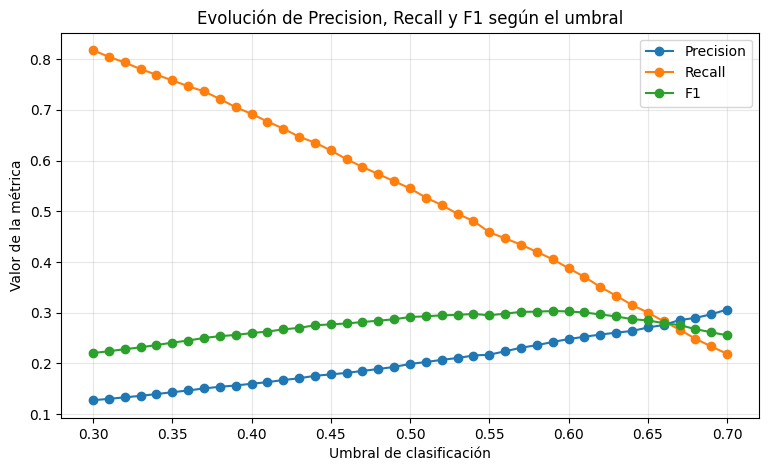

In [73]:
# =========================================================
# 26. THRESHOLD METRICS PLOT
# =========================================================

plt.figure(figsize=(9, 5))

plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], marker="o", label="F1")

plt.title("Evolución de Precision, Recall y F1 según el umbral")
plt.xlabel("Umbral de clasificación")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [74]:
# Selected operating threshold
selected_threshold = 0.52

best_oof_df["y_pred_selected"] = (
    best_oof_df["y_proba"] >= selected_threshold
).astype(int)

cm_selected = confusion_matrix(
    best_oof_df["y_true"],
    best_oof_df["y_pred_selected"]
)

cm_selected

array([[30436,  6335],
       [ 1575,  1654]])

In [75]:
# =========================================================
# 27. DECILE ANALYSIS OF BEST MODEL
# =========================================================

best_decile_table = decile_lift_capture_table(
    oof_df=best_oof_df,
    model_name=best_model_name
)

best_decile_table[[
    "risk_decile",
    "n_clients",
    "n_defaults",
    "default_rate_pct",
    "lift",
    "capture_rate",
    "cum_lift"
]].round(4)

,risk_decile,n_clients,n_defaults,default_rate_pct,lift,capture_rate,cum_lift
0,1,4000,1051,26.275,3.2549,0.3255,3.2549
1,2,4000,605,15.125,1.8736,0.5129,2.5643
2,3,4000,416,10.400,1.2883,0.6417,2.1389
3,4,4000,316,7.900,0.9786,0.7395,1.8489
4,5,4000,212,5.300,0.6566,0.8052,1.6104
5,6,4000,200,5.000,0.6194,0.8671,1.4452
6,7,4000,149,3.725,0.4614,0.9133,1.3047
7,8,4000,124,3.100,0.3840,0.9517,1.1896
8,9,4000,90,2.250,0.2787,0.9796,1.0884
9,10,4000,66,1.650,0.2044,1.0000,1.0000


In [76]:
# Cumulative lift table
cumulative_lift_table = best_decile_table[[
    "risk_decile",
    "cum_clients",
    "cum_defaults",
    "cum_client_pct",
    "capture_rate",
    "cum_default_rate",
    "cum_lift"
]].copy()

cumulative_lift_table.round(4)

,risk_decile,cum_clients,cum_defaults,cum_client_pct,capture_rate,cum_default_rate,cum_lift
0,1,4000,1051,0.1,0.3255,0.2628,3.2549
1,2,8000,1656,0.2,0.5129,0.2070,2.5643
2,3,12000,2072,0.3,0.6417,0.1727,2.1389
3,4,16000,2388,0.4,0.7395,0.1492,1.8489
4,5,20000,2600,0.5,0.8052,0.1300,1.6104
5,6,24000,2800,0.6,0.8671,0.1167,1.4452
6,7,28000,2949,0.7,0.9133,0.1053,1.3047
7,8,32000,3073,0.8,0.9517,0.0960,1.1896
8,9,36000,3163,0.9,0.9796,0.0879,1.0884
9,10,40000,3229,1.0,1.0000,0.0807,1.0000


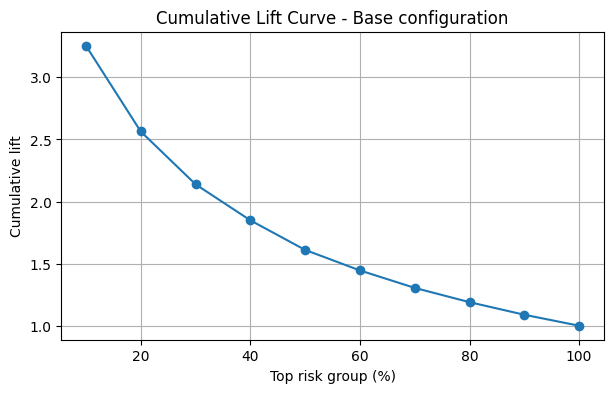

In [77]:
# =========================================================
# 28. CUMULATIVE LIFT CURVE
# =========================================================

plt.figure(figsize=(7, 4))

plt.plot(
    cumulative_lift_table["cum_client_pct"] * 100,
    cumulative_lift_table["cum_lift"],
    marker="o"
)

plt.xlabel("Top risk group (%)")
plt.ylabel("Cumulative lift")
plt.title(f"Cumulative Lift Curve - {best_model_name}")
plt.grid(True)
plt.show()

# 12. Evaluación final en test
Una vez seleccionado el modelo mediante validación cruzada sobre train, se entrena el modelo final con todo el conjunto de entrenamiento y se evalúa una única vez sobre el test reservado. Esta evaluación representa el rendimiento final fuera de muestra.

In [78]:
# =========================================================
# 30. FINAL MODEL ON TEST SET
# =========================================================

best_config = next(
    config for config in tuning_configs
    if config["model"] == best_model_name
)

X_train_final = df_model_train_final.drop(columns=["TARGET"]).copy()
y_train_final = df_model_train_final["TARGET"].copy()

X_test_final = df_model_test_final.drop(columns=["TARGET"]).copy()
y_test_final = df_model_test_final["TARGET"].copy()

print("Modelo evaluado en TEST:", best_model_name)
print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)

Modelo evaluado en TEST: Base configuration
Train: (40000, 62)
Test: (267511, 62)


In [79]:
# Same preprocessing, fitted on train and applied to test
X_train_final, X_test_final = preprocess_fold(
    X_train_final,
    X_test_final
)

In [80]:
# Train final model and evaluate on test
scale_pos_weight_base = (y_train_final == 0).sum() / (y_train_final == 1).sum()
scale_pos_weight = scale_pos_weight_base * 0.75

params = best_config["params"].copy()
params["scale_pos_weight"] = scale_pos_weight

final_model = XGBClassifier(**params)

final_model.fit(X_train_final, y_train_final)

y_test_proba = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = final_model.predict(X_test_final)

test_metrics = pd.DataFrame([{
    "model": best_model_name,
    "accuracy": accuracy_score(y_test_final, y_test_pred),
    "precision": precision_score(y_test_final, y_test_pred, zero_division=0),
    "recall": recall_score(y_test_final, y_test_pred, zero_division=0),
    "f1": f1_score(y_test_final, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test_final, y_test_proba),
    "pr_auc": average_precision_score(y_test_final, y_test_proba)
}])

test_metrics.round(4)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Base configuration,0.7828,0.1955,0.5429,0.2875,0.749,0.2332


In [81]:
# Test confusion matrix
cm_test = confusion_matrix(y_test_final, y_test_pred)

cm_test

array([[197673,  48242],
       [  9871,  11725]])

In [82]:
# =========================================================
# 31. TEST SET: DECILES, LIFT AND CAPTURE
# =========================================================

test_scoring_df = pd.DataFrame({
    "y_true": y_test_final.values,
    "y_proba": y_test_proba
})

test_decile_table = decile_lift_capture_table(
    oof_df=test_scoring_df,
    model_name=best_model_name
)

test_decile_table[[
    "risk_decile",
    "n_clients",
    "n_defaults",
    "default_rate_pct",
    "lift",
    "capture_rate",
    "cum_lift"
]].round(4)

,risk_decile,n_clients,n_defaults,default_rate_pct,lift,capture_rate,cum_lift
0,1,26751,7062,26.3990,3.2701,0.3270,3.2701
1,2,26751,3919,14.6499,1.8147,0.5085,2.5424
2,3,26751,2737,10.2314,1.2674,0.6352,2.1174
3,4,26751,2126,7.9474,0.9844,0.7337,1.8341
4,5,26751,1651,6.1717,0.7645,0.8101,1.6202
5,6,26751,1321,4.9381,0.6117,0.8713,1.4521
6,7,26751,1068,3.9924,0.4945,0.9207,1.3153
7,8,26751,787,2.9419,0.3644,0.9572,1.1965
8,9,26751,569,2.1270,0.2635,0.9835,1.0928
9,10,26752,356,1.3307,0.1648,1.0000,1.0000


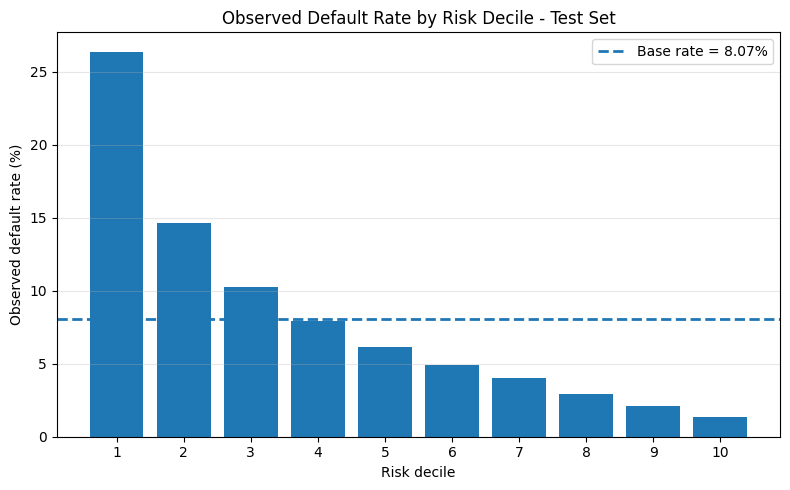

In [83]:
# =========================================================
# 32. TEST SET: DEFAULT RATE BY RISK DECILE
# =========================================================

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 5))

plt.bar(
    test_decile_table["risk_decile"].astype(str),
    test_decile_table["default_rate_pct"]
)

plt.axhline(
    y_test_final.mean() * 100,
    linestyle="--",
    linewidth=2,
    label=f"Base rate = {y_test_final.mean() * 100:.2f}%"
)

plt.xlabel("Risk decile")
plt.ylabel("Observed default rate (%)")
plt.title("Observed Default Rate by Risk Decile - Test Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/default_rate_by_risk_decile_test.pdf",
    bbox_inches="tight"
)

plt.show()

In [88]:
# =========================================================
# 33. TEST SET: CUMULATIVE CAPTURE TOP 10%, 20% AND 30%
# =========================================================

capture_top_table = (
    test_decile_table[test_decile_table["risk_decile"].isin([1, 2, 3])]
    [[
        "risk_decile",
        "cum_clients",
        "cum_defaults",
        "capture_rate",
        "cum_lift"
    ]]
    .copy()
)

capture_top_table["Top risk group"] = [
    "Top 10%",
    "Top 20%",
    "Top 30%"
]

capture_top_table["capture_rate_pct"] = (
    capture_top_table["capture_rate"] * 100
)

capture_top_table = capture_top_table[[
    "Top risk group",
    "cum_clients",
    "cum_defaults",
    "capture_rate_pct",
    "cum_lift"
]]

capture_top_table.round(2)

,Top risk group,cum_clients,cum_defaults,capture_rate_pct,cum_lift
0,Top 10%,26751,7062,32.70,3.27
1,Top 20%,53502,10981,50.85,2.54
2,Top 30%,80253,13718,63.52,2.12


In [87]:
# =========================================================
# 34. FEATURE IMPORTANCE - FINAL XGBOOST MODEL
# =========================================================

feature_importance_df = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": final_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(20)

,feature,importance
0,EXT_SOURCE_MEAN,0.085487
1,EXT_SOURCE_MAX,0.038390
2,n_closed_credits_GROUP_0,0.030918
3,NAME_EDUCATION_TYPE_GROUP_Higher education / A...,0.020955
4,NAME_EDUCATION_TYPE_GROUP_Secondary / secondar...,0.015842
5,EXT_SOURCE_MIN,0.014787
6,CODE_GENDER_M,0.014567
7,ratio_closed_credits,0.014535
8,FLAG_OWN_CAR_Y,0.013769
9,n_refused_previous_GROUP_0,0.013143


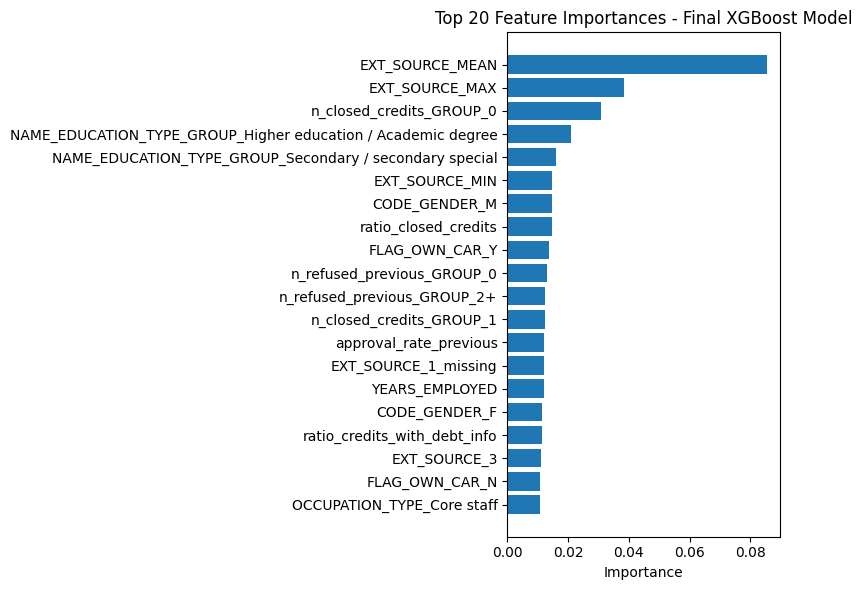

In [86]:
# Top 20 feature importances
top_features = feature_importance_df.head(20)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Final XGBoost Model")
plt.tight_layout()

plt.savefig(
    "figures/feature_importance_xgboost_final.pdf",
    bbox_inches="tight"
)

plt.show()